In [3]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [4]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [5]:
color_list = palette_tab10[2:3] + palette_tab10[4:5] + palette_tab10[1:2] 

In [6]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [7]:
snapnum = 40

In [8]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [183]:
halo_path = f"{basePath}/postprocessing/halo_structure"
fname_halo = f"{halo_path}/halo_structure_0{snapnum}.hdf5"
f = h5py.File(fname_halo, 'r')

In [9]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [185]:
h0 = 0.6774

In [10]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [259]:
group_sfrs = np.log10(halos["GroupSFR"])
#group_sfrs = halos["GroupSFR"]

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


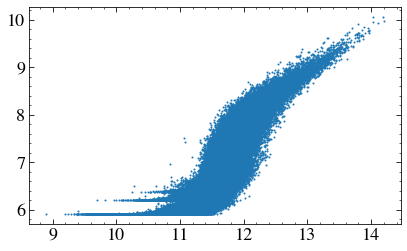

In [12]:
plt.scatter(mvir, np.log10(halos["GroupBHMass"]*1e10), s=1)

In [13]:
stats.spearmanr(mvir,halos["GroupBHMass"])

SpearmanrResult(correlation=0.27938957281349613, pvalue=0.0)

In [188]:
m200c = np.log10((10**np.array(f["M200c"]))*h0)
c200c = np.array(f["c200c"])
Mdyn = np.array(f["M_acc_dyn"])
frac_cent = np.array(f["f_mass_Cen"])

In [189]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12
<class 'dict'>


In [190]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

In [191]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [192]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [193]:
cent_cprox = cent_vmax/cent_rmax

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [194]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [195]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [260]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [209]:
cent_submass = np.zeros(len(mvir))
cent_submass[halos["GroupFirstSub"]>-1] = subhalos["SubhaloMass"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_submass = np.log10(cent_submass*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [217]:
cent_bhmass = np.zeros(len(mvir))
cent_bhmass[halos["GroupFirstSub"]>-1] = subhalos["SubhaloBHMass"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_bhmass = np.log10(cent_submass*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


### Satellite SFR

In [197]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [198]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [199]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [200]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [261]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


In [202]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [262]:

sum_sat_mass = np.zeros(len(group_sfrs))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in log10
  after removing the cwd from sys.path.


### Correlation coefficient

In [263]:
sfr_types = [cent_sfrs, sum_sfrs, group_sfrs]

In [73]:
sfr_type_names = ["Central", "Satellite", "Group"]

In [43]:
frac_cent

array([0.70381984, 0.91247133, 0.90123285, ...,        nan,        nan,
              nan])

In [395]:
property1 = cent_cprox

In [397]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists = []
perr_lists = []

for itype in range(3):
    coef_list = []
    perr_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        coef1 = stats.spearmanr(property1[mask],sfr_types[itype][mask])
        coef = coef1[0]
        perr = coef1[1]
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
        perr_list.append(perr)
    coef_lists.append(coef_list)
    perr_lists.append(perr_list)

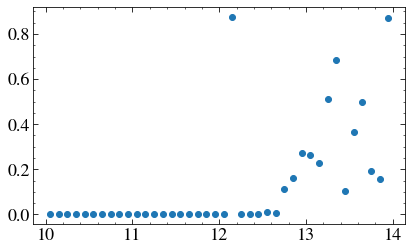

In [336]:
plt.scatter(mbin_cents, perr_lists[0])

In [398]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.3])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists1 =[]
for itype in range(3):
    coef_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        if np.sum(mask) > 0:
            percentiles = np.percentile(sfr_types[itype][mask], 99)
            median = np.median(sfr_types[itype][mask])
            diff = percentiles-median
            low_lim = median-diff
            mask = mask & (sfr_types[itype] > low_lim)
        coef = stats.spearmanr(property1[mask],sfr_types[itype][mask])[0]
        
        
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
    coef_lists1.append(coef_list)

In [315]:
print(mbin_cents)
print(coef_lists[0])

[10.05 10.15 10.25 10.35 10.45 10.55 10.65 10.75 10.85 10.95 11.05 11.15
 11.25 11.35 11.45 11.55 11.65 11.75 11.85 11.95 12.05 12.15 12.25 12.35
 12.45 12.55 12.65 12.75 12.85 12.95 13.05 13.15 13.25 13.35 13.45 13.55
 13.65 13.75 13.8  14.05]
[0.1230654808562168, 0.13069839233586977, 0.1380779873530569, 0.1537234012871674, 0.1818395771239043, 0.2150014804126918, 0.28099821283670423, 0.34829509323382535, 0.425010529459927, 0.49570382248605516, 0.5632240547775675, 0.6103438104540992, 0.6437362987409542, 0.6391840609670539, 0.5881378623208585, 0.4977932565159651, 0.41516834250308093, 0.37050624727782205, 0.3270537504460799, 0.22467184773856383, 0.10094325347764324, -0.01789628487733913, -0.05750941651812728, -0.13088893576935037, -0.1510392056243597, -0.19504638123886656, -0.30673730140908756, -0.27621603565336095, -0.2519204399120653, -0.11293612987261804, -0.21457912392841352, 0.02798624212561014, -0.11933469253843268, -0.1396156086196855, -0.3918010752688173, 0.019367588932806323, 0.

In [ ]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(1):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])
#for itype in range(1):
#    plt.plot(mbin_cents, coef_lists1[itype], label=sfr_type_names[itype], color=color_list[itype],alpha=0.5, linestyle="dashed")

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", bbox_to_anchor=(0,0.7))
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,1))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_msat.pdf", format="pdf", bbox_inches="tight")

(11.0, 14.4)

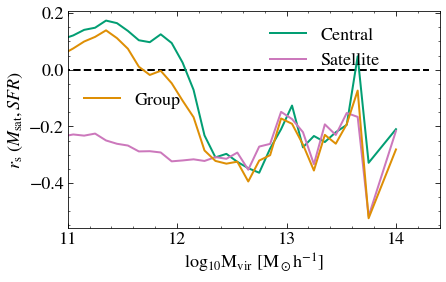

In [364]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])
#for itype in range(1):
#    plt.plot(mbin_cents, coef_lists1[itype], label=sfr_type_names[itype], color=color_list[itype],alpha=0.5, linestyle="dashed")

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", bbox_to_anchor=(0,0.7))
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,1))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_msat.pdf", format="pdf", bbox_inches="tight")

In [99]:
dlogM=0.1
m = 12
mask = (np.isnan(c200c) == False) & (mvir > m - dlogM) & (mvir < m + dlogM)
coef = stats.spearmanr(c200c[mask],cent_cprox[mask])
print(coef)

SpearmanrResult(correlation=0.363392113938942, pvalue=0.0)


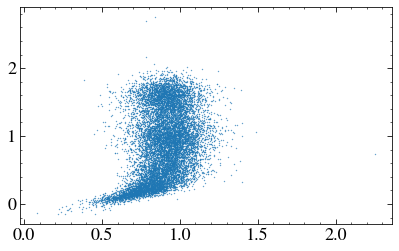

In [100]:
plt.scatter(np.log10(c200c[mask]), np.log10(cent_cprox[mask]), s=0.1)

Text(0, 0.5, 'log(Vmax/rmax)')

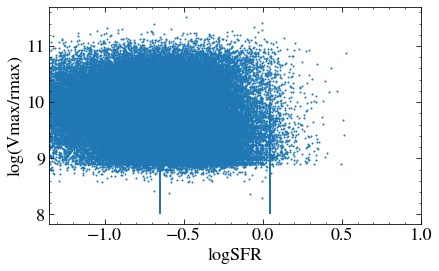

In [296]:
m = 11
dlogM=0.1
mask2 = (mvir > m - dlogM) & (mvir < m + dlogM) & (group_sfrs > -5)
itype=0
percentiles = np.percentile(sfr_types[itype][mask2], 99)
median = np.median(sfr_types[itype][mask2])
diff = percentiles-median
low_lim = median-diff
plt.scatter(sfr_types[itype][mask2],sum_sat_mass[mask2],  s=1)
plt.vlines(median, ymin=8, ymax=10)
plt.vlines(percentiles, ymin=8, ymax=10)
plt.vlines(median-(percentiles-median), ymin=8, ymax=10)
plt.xlim(median-(percentiles-median), 1)
plt.xlabel("logSFR")
plt.ylabel("log(Vmax/rmax)")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in log10
  if sys.path[0] == '':


Text(0.1, 0.85, '$r_\\mathrm{s} = -0.19$')

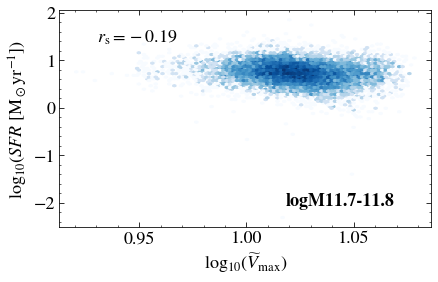

In [371]:
m = 11.7
dlogM=0.1
mask = (mvir > m) & (mvir < m + dlogM) & (group_sfrs > -5) #& (np.isnan(c200c)==False)
for itype in range(0,1):
    x = sum_sat_mass[mask]
    y = sfr_types[itype][mask]
    coef = stats.spearmanr(x,y)[0]
    #plt.scatter(np.log10(x), y, s=0.1, label=sfr_type_names[itype])
#plt.legend(loc="lower right", markerscale=10)
plt.ylabel(r"$\rm log_{10}($$SFR$ $\rm[M_\odot yr^{-1}])$")
plt.xlabel(r"$ \log_{10}(\widetilde{V}_{\mathrm{max}}$)")
hb = plt.hexbin(np.log10(x), y, gridsize=100, cmap='Blues', bins="log",mincnt=1)

logM_name = f"logM{m}-{np.round(m+0.1,1)}"
plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_msat_{logM_name}.pdf", format="pdf", bbox_inches="tight")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in log10
  if sys.path[0] == '':


Text(0.1, 0.85, '$r_\\mathrm{s} = 0.29$')

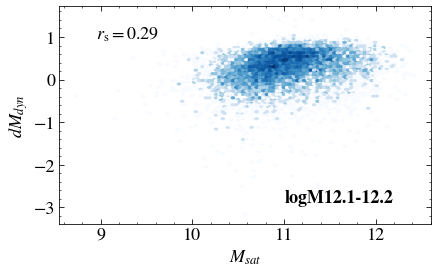

In [189]:
m = 12.1
dlogM=0.1
mask = (mvir > m - dlogM) & (mvir < m + dlogM) & (group_sfrs > -5) & (np.isnan(Mdyn)==False)#& (np.isnan(c200c)==False)
for itype in range(2,3):
    x = sum_sat_mass[mask]
    y = Mdyn[mask]
    coef = stats.spearmanr(x,y)[0]
    #plt.scatter(np.log10(x), y, s=0.1, label=sfr_type_names[itype])
#plt.legend(loc="lower right", markerscale=10)
plt.ylabel(r"$dM_{dyn}$")
plt.xlabel(r"$M_{sat}$")
hb = plt.hexbin(x, np.log10(y), gridsize=100, cmap='Blues', bins="log",mincnt=1)

logM_name = f"logM{m}-{np.round(m+0.1,1)}"
plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_msat_{logM_name}.pdf", format="pdf", bbox_inches="tight")

[-3.3773096   1.09159125  2.1674998   3.60808336  9.87121592]


Text(0.1, 0.85, '$r_\\mathrm{s} = 0.45$')

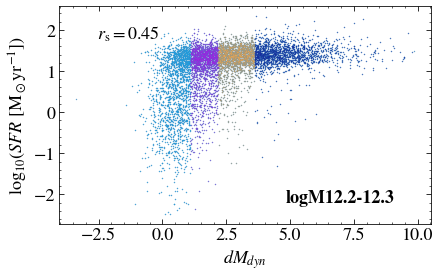

In [180]:
m = 12.2
dlogM=0.1
mask = (mvir > m - dlogM) & (mvir < m + dlogM) & (group_sfrs > -5) & (sum_sfrs > -5) & (Mdyn < 10) & (np.isnan(Mdyn)==False)#& (np.isnan(c200c)==False)
for itype in range(2,3):
    x = Mdyn[mask]
    y = sfr_types[itype][mask]
    coef = stats.pearsonr(x,y)[0]
    plt.scatter(x, y, s=0.1, label=sfr_type_names[itype])
#plt.legend(loc="lower right", markerscale=10)
plt.ylabel(r"$\rm log_{10}($$SFR$ $\rm[M_\odot yr^{-1}])$")
#plt.xlabel(r"$ \log_{10}(\widetilde{V}_{\mathrm{max}}$)")
plt.xlabel(r"$dM_{dyn}$")
#hb = plt.hexbin(np.log10(x), y, gridsize=100, cmap='Blues', bins="log",mincnt=1)

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(x, percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask1 = (x > percentiles[i]) & (x < percentiles[i+1])
    masks.append(mask)
    plt.scatter(x[mask1], group_sfrs[mask][mask1], label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.5, color=color_list[i], s=0.1)# facecolor="none", edgecolor=color_list[i])


logM_name = f"logM{m}-{np.round(m+0.1,1)}"
plt.annotate(f"{logM_name}", (0.9,0.1), xycoords="axes fraction", ha="right", weight="bold")
plt.annotate(rf"$r_\mathrm{{s}} = {np.round(coef,2)}$", (0.1,0.85), xycoords="axes fraction", ha="left")
#plt.savefig(f"../figures/sfr_vmax_{logM_name}.pdf", format="pdf", bbox_inches="tight")

[-1.09934244  1.03470503  2.16871095  3.61063187 24.61813475]


Text(0.3, 0.85, 'Split by ')

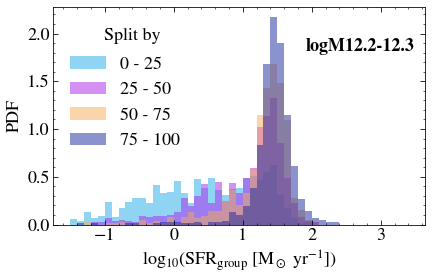

In [171]:
bins=np.arange(-1.5, 3.5, 0.1)

property1 = Mdyn
x = property1

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
logM = 12.2
mask2 = (mvir> logM) & (mvir < logM+0.1)

median = np.nanmedian(x[mask2])
mask_high = x[mask2] > median
mask_low = x[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(x[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (x[mask2] > percentiles[i]) & (x[mask2] < percentiles[i+1])
    masks.append(mask)
    plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.5, color=color_list[i])#,histtype='step')# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm group}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.97,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"Split by ", (0.3,0.85), xycoords="axes fraction", ha="right")
#plt.savefig("../figures/hist_logM12.4-12.5_msat.pdf", format="pdf", bbox_inches="tight")

In [79]:
n_nan = []
frac_nan = []
for mcent in mbin_cents:
    mask = (mvir > mcent - dlogM) & (mvir < mcent + dlogM) & (group_sfrs > -5) & (np.isnan(Mdyn)==True)
    
    mask1 = (mvir > mcent - dlogM) & (mvir < mcent + dlogM) & (group_sfrs > -5) #& (np.isnan(Mdyn)==True)
    n = np.sum(mask)
    n_nan.append(n)
    frac_nan.append(n/np.sum(mask1))

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


Text(0, 0.5, 'Frac nan')

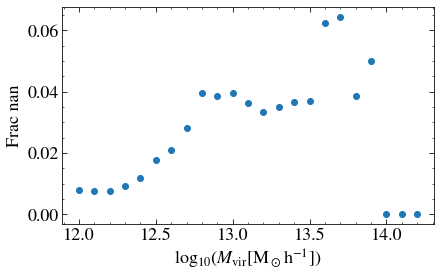

In [80]:
plt.scatter(mbin_cents[20:], frac_nan[20:])
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.ylabel(r"Frac nan")

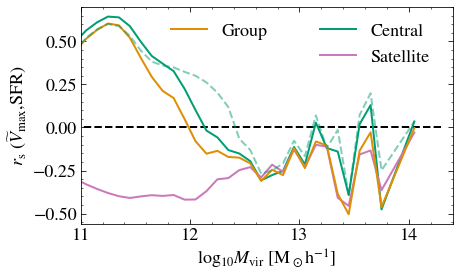

In [403]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])
    
for itype in range(1):
    plt.plot(mbin_cents, coef_lists1[itype], label=sfr_type_names[itype], color=color_list[itype],alpha=0.5, linestyle="dashed")

plt.xlabel(r"log$_{10} M_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ $($\widetilde{V}_{\mathrm{max}}$,SFR)")
#plt.ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}, \widetilde{V}_{\mathrm{max}})$")

ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:-1], labels=l[2:-1], loc = "upper left", bbox_to_anchor=(0.2,1))
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.6,1))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_vmax_95th.pdf", format="pdf", bbox_inches="tight")

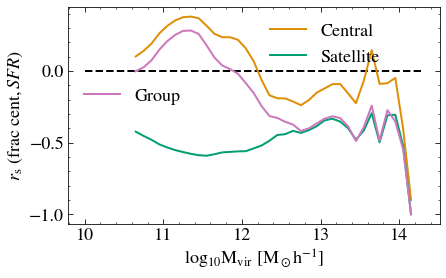

In [47]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (\mathrm{frac\ cent}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", ncol=2, bbox_to_anchor=(0,0.7))
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,1))

#plt.savefig("../figures/corr_coef_conc_notnan.pdf", format="pdf", bbox_inches="tight")

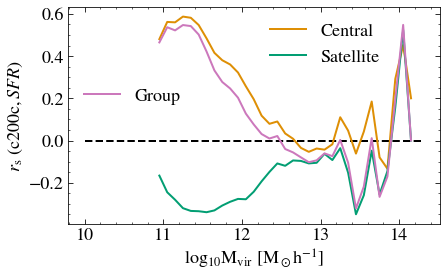

In [109]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (\mathrm{c200c}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", ncol=2, bbox_to_anchor=(0,0.7))
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,1))

#plt.savefig("../figures/corr_coef_conc_notnan.pdf", format="pdf", bbox_inches="tight")

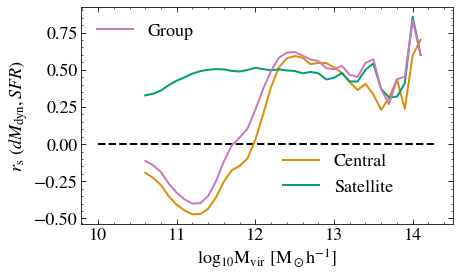

In [73]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (dM_{\mathrm{dyn}}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", ncol=2, bbox_to_anchor=(0,1))
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,0.4))

#plt.savefig("../figures/corr_coef_dMdyn_notnan.pdf", format="pdf", bbox_inches="tight")

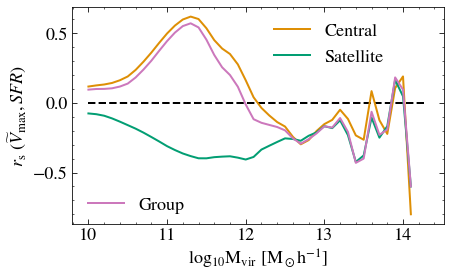

In [56]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ ( \widetilde{V}_{\mathrm{max}}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", ncol=2, bbox_to_anchor=(0,0.2))
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,1))

#plt.savefig("../figures/corr_coef_conc_prox.pdf", format="pdf", bbox_inches="tight")

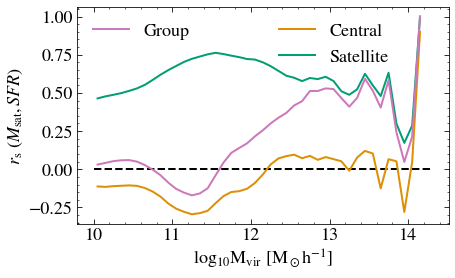

In [91]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10}$M$_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}, SFR)$")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "upper left", ncol=2)
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0.5,1))

#plt.savefig("../figures/corr_coef_msat.pdf", format="pdf", bbox_inches="tight")

In [392]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists = []
perr_lists = []

for itype in range(3):
    coef_list = []
    perr_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        coef1 = stats.spearmanr(sum_sat_mass[mask]/mvir[mask],sfr_types[itype][mask])
        coef = coef1[0]
        perr = coef1[1]
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
        perr_list.append(perr)
    coef_lists.append(coef_list)
    perr_lists.append(perr_list)

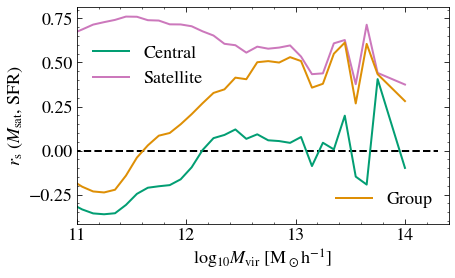

In [394]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(3):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[itype])

plt.xlabel(r"log$_{10} M_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}$, SFR)")
ax = plt.gca()
h, l =  ax.get_legend_handles_labels()
leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
ax.add_artist(leg1)
leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_msat.pdf", format="pdf", bbox_inches="tight")

In [328]:
mbin_cents

array([10.05, 10.15, 10.25, 10.35, 10.45, 10.55, 10.65, 10.75, 10.85,
       10.95, 11.05, 11.15, 11.25, 11.35, 11.45, 11.55, 11.65, 11.75,
       11.85, 11.95, 12.05, 12.15, 12.25, 12.35, 12.45, 12.55, 12.65,
       12.75, 12.85, 12.95, 13.05, 13.15, 13.25, 13.35, 13.45, 13.55,
       13.65, 13.75, 14.05])

In [373]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists = []
perr_lists = []

for itype in range(1):
    coef_list = []
    perr_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        coef1 = stats.spearmanr(cent_cprox[mask],sum_sat_mass[mask])
        coef = coef1[0]
        perr = coef1[1]
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
        perr_list.append(perr)
    coef_lists.append(coef_list)
    perr_lists.append(perr_list)

In [374]:
import matplotlib.ticker as ticker

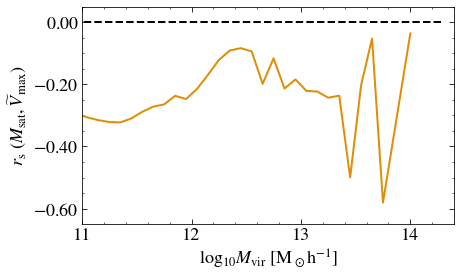

In [386]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(1):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[2])

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:.2f}$'))

ax.set_xlabel(r"log$_{10} M_{\rm vir}$ [M$_\odot$h$^{-1}$]")
ax.set_ylabel(r"$r_\mathrm{s}\ (M_{\mathrm{sat}}, \widetilde{V}_{\rm max})$")


# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
plt.ylim(-0.65, 0.05)
#plt.savefig("../figures/corr_coef_msat_vmax.pdf", format="pdf", bbox_inches="tight")

In [387]:
dlogM = 0.1
mbins = np.arange(10,13.71,dlogM)
mbins2 = np.array([13.8, 14.2])
mbins = np.concatenate((mbins, mbins2))
mbin_cents = (mbins[1:] + mbins[:-1])/2

coef_lists = []
perr_lists = []

for itype in range(1):
    coef_list = []
    perr_list = []
    for i, m in enumerate(mbins[:-1]):
        mask = (mvir > mbins[i]) & (mvir < mbins[i+1]) & (group_sfrs > -5) #& (np.isnan(frac_cent) == False)#& (np.isnan(c200c)==False)
        # frac = np.sum(mask)/np.sum((mvir > mcent - dlogM/2) & (mvir < mcent + dlogM/2) )
        # frac_list.append(frac)
        coef1 = stats.spearmanr(sfr_types[0][mask],sfr_types[1][mask])
        coef = coef1[0]
        perr = coef1[1]
        if np.sum(mask) < 5:
            coef = np.nan
            #print(mcent)
        coef_list.append(coef)
        perr_list.append(perr)
    coef_lists.append(coef_list)
    perr_lists.append(perr_list)

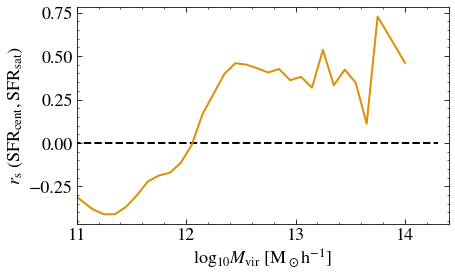

In [389]:
plt.plot([10,14.3], [0,0], linestyle="dashed", c="k")
for itype in range(1):
    plt.plot(mbin_cents, coef_lists[itype], label=sfr_type_names[itype], color=color_list[2])

plt.xlabel(r"log$_{10} M_{\rm vir}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"$r_\mathrm{s}\ \rm(SFR_{cent}, SFR_{sat})$")
# ax = plt.gca()
# h, l =  ax.get_legend_handles_labels()
# leg1 = plt.legend(handles=h[2:], labels=l[2:], loc = "lower right", ncol=2)
# ax.add_artist(leg1)
# leg2 = plt.legend(handles=h[:2], labels=l[:2], loc = "upper left", bbox_to_anchor=(0,0.9))
plt.xlim(11,14.4)
#plt.savefig("../figures/corr_coef_sfr_cent_sat.pdf", format="pdf", bbox_inches="tight")